# Mandengue — Objectif 2 : EDA & Modèle par type de bien
Analyse exploratoire + Random Forest séparé Maison / Appartement.

In [1]:
pip install pandas numpy matplotlib scikit-learn seaborn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, sys
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sys.path.insert(0, os.path.dirname(os.getcwd()))
import config
print(' config.py chargé')

 config.py chargé


## 1. Charger data_clean.csv (produit par Arthur)

In [3]:
df = pd.read_csv(config.DATA_CLEAN)
print(f' {len(df)} lignes chargées depuis data_clean.csv')
print(df[config.COL_TYPE].value_counts())

 9330 lignes chargées depuis data_clean.csv
type_local
Maison         6874
Appartement    2456
Name: count, dtype: int64


## 2. EDA — Distribution des prix

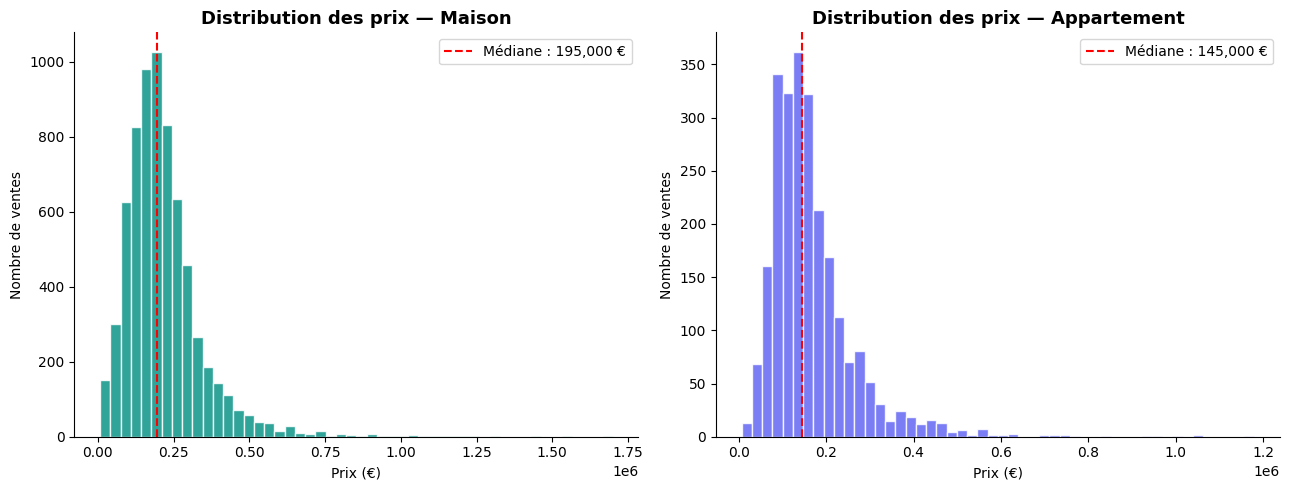

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
couleurs = {'Maison': '#0D9488', 'Appartement': '#6366F1'}

for ax, type_bien in zip(axes, config.TYPES_BIENS):
    data = df[df[config.COL_TYPE] == type_bien][config.COL_PRIX]
    ax.hist(data, bins=50, color=couleurs[type_bien], edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Médiane : {data.median():,.0f} €')
    ax.set_title(f'Distribution des prix — {type_bien}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prix (€)')
    ax.set_ylabel('Nombre de ventes')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'mandengue_distribution_prix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. EDA — Heatmap de corrélation

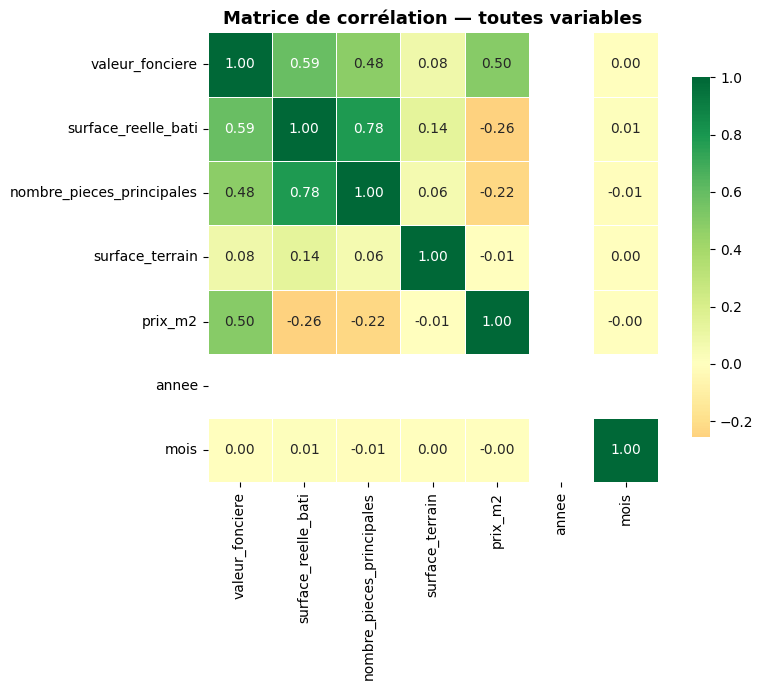

In [5]:
cols_corr = [config.COL_PRIX, config.COL_SURFACE, config.COL_PIECES,
             config.COL_TERRAIN, 'prix_m2', 'annee', 'mois']

corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation — toutes variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'mandengue_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. EDA — Prix au m² par type de bien et par année

In [6]:
stats = df.groupby([config.COL_TYPE, 'annee']).agg(
    prix_moyen    = (config.COL_PRIX, 'mean'),
    prix_m2_moyen = ('prix_m2',       'mean'),
    nb_ventes     = (config.COL_PRIX, 'count')
).round(0).reset_index()

print(stats.to_string(index=False))

# Sauvegarder les features choisies
FEATURES_MANDENGUE = [
    config.COL_SURFACE,
    config.COL_PIECES,
    config.COL_TERRAIN,
    config.COL_LAT,
    config.COL_LON,
    'annee',
    'mois',
]
print('\nFeatures retenues :', FEATURES_MANDENGUE)

 type_local  annee  prix_moyen  prix_m2_moyen  nb_ventes
Appartement   2024    167496.0         3061.0       2456
     Maison   2024    216552.0         2129.0       6874

Features retenues : ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'latitude', 'longitude', 'annee', 'mois']


## 5. Export features_list.py

In [7]:
features_content = f'''# features_list.py — produit par Mandengue
# Variables sélectionnées après analyse EDA

FEATURES = {FEATURES_MANDENGUE}

# Justification :
# - surface_reelle_bati : corrélation la plus forte avec le prix
# - nombre_pieces_principales : lié à la surface, bon complément
# - surface_terrain : important pour les maisons
# - latitude / longitude : capture l'effet zone géographique
# - annee / mois : capture la tendance temporelle
'''

with open(config.FEATURES_LIST, 'w') as f:
    f.write(features_content)

print(' features_list.py exporté')

 features_list.py exporté


## 6. Modèle Random Forest — Maison

In [8]:
df_maison = df[df[config.COL_TYPE] == 'Maison'].copy()

X = df_maison[FEATURES_MANDENGUE].fillna(0)
y = df_maison[config.COL_PRIX]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_maison = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_maison.fit(X_train, y_train)
y_pred = rf_maison.predict(X_test)

print('=== Random Forest — Maison ===')
print(f'R²   : {r2_score(y_test, y_pred):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):,.0f} €')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} €')

=== Random Forest — Maison ===
R²   : 0.6445
MAE  : 51,756 €
RMSE : 75,874 €


## 7. Modèle Random Forest — Appartement

In [9]:
df_appart = df[df[config.COL_TYPE] == 'Appartement'].copy()

X = df_appart[FEATURES_MANDENGUE].fillna(0)
y = df_appart[config.COL_PRIX]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_appart = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_appart.fit(X_train, y_train)
y_pred = rf_appart.predict(X_test)

print('=== Random Forest — Appartement ===')
print(f'R²   : {r2_score(y_test, y_pred):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):,.0f} €')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} €')

=== Random Forest — Appartement ===
R²   : 0.5699
MAE  : 41,082 €
RMSE : 76,944 €


## 8. Comparaison importance features Maison vs Appartement

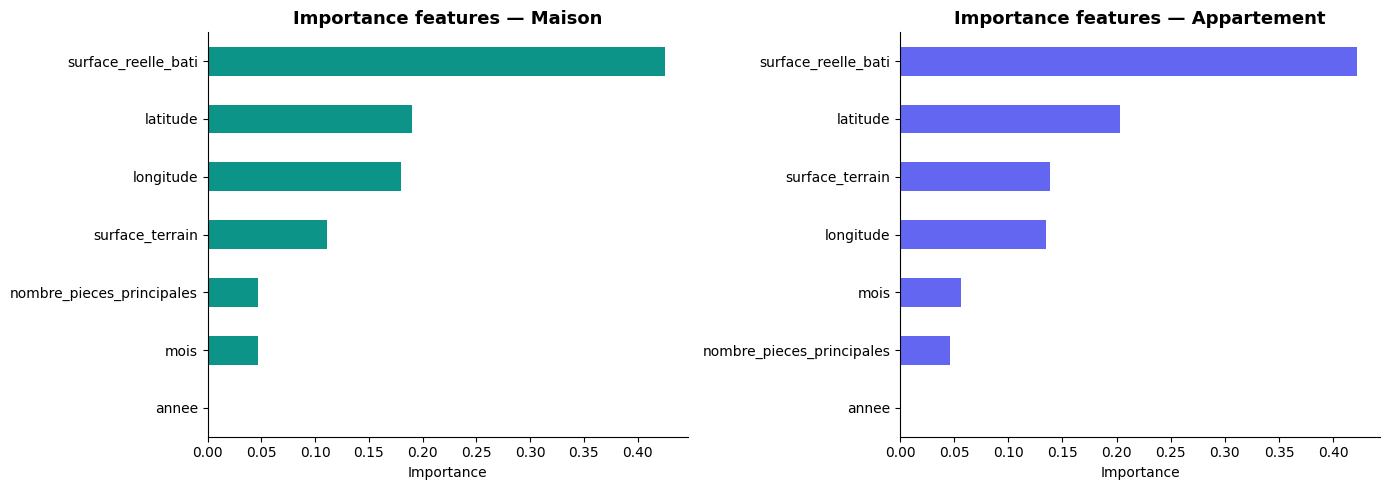

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, titre, c in zip(
    axes,
    [rf_maison, rf_appart],
    ['Maison', 'Appartement'],
    ['#0D9488', '#6366F1']
):
    imp = pd.Series(model.feature_importances_, index=FEATURES_MANDENGUE).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color=c)
    ax.set_title(f'Importance features — {titre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'mandengue_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Export model_obj2.pkl

In [11]:
# On exporte les 2 modèles dans un dictionnaire
model_obj2 = {'Maison': rf_maison, 'Appartement': rf_appart, 'features': FEATURES_MANDENGUE}

with open(config.MODEL_OBJ2, 'wb') as f:
    pickle.dump(model_obj2, f)

print(' model_obj2.pkl exporté (Maison + Appartement)')

 model_obj2.pkl exporté (Maison + Appartement)
